# Healthcare-Style Speech Evaluation

## 1 Overview

This notebook provides a functional test of the Solace pipeline using controlled healthcare data. Instead of an academic emotion dataset, it uses a small set of healthcare-style spoken reflections, scripted to sound like a nurse or doctor talking about a shift, and covering clearly positive (High wellbeing), clearly negative (Low) and deliberately ambiguous (Mixed) samples, and runs them through the full pipeline and checks whether each channel and their combination places the clip in the expected wellbeing band.

It stores the text, audio, and vision strain and the supporting speech and visual signals for each recording, converts them into wellbeing bands, and compares the text, audio, vision, text-plus-audio and median-multimodal configurations to the expected label. The set is small and purpose built, so the results are a targeted check on channel performance on realistic healthcare speech, and where they fail, not a large-scale accuracy benchmark.

## 2 Import Libraries

This section imports the small toolchain the evaluation needs. per-clip results table and score arithmetic are done with pandas and NumPy, accuracy and macro-F1 helpers are provided by scikit-learn, per-clip comparison chart is drawn with matplotlib, and sys is imported so that the project root can be placed on the path and Solace pipeline can be imported in the next section.

In [1]:
# Hide warnings and library logs
import os
import warnings
import logging

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

In [2]:
# import required libraies
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

As with the other pipeline-level notebooks, the dependency list is light because the work is orchestration running the deployed scorer over a set of clips and tabulating the outcome rather than model training.  The check is functional and reproducible due to the explicit imports up front. The next section loads the pipeline itself .

## 3 Load Solace Pipeline

This section places the project root on the Python path and instantiates the MultimodalPipeline the very object the live application uses so the recordings are scored by the real production system rather than a re-implementation. The check only becomes meaningful as a test of the deployed tool when the real pipeline is loaded.

In [3]:
# project root
PROJECT_ROOT = Path.cwd().parents[1]

In [4]:
# if project root not in path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
# import pipeline
from UI.ai.multimodal_pipeline import MultimodalPipeline
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP


In [6]:
# load the pipeline
pipeline = MultimodalPipeline()
# print "Solace pipeline loaded."
print("Solace pipeline loaded")

Solace pipeline loaded


The production scorer is being used directly, so each band and score below is what a real user would get, which is exactly the point of a healthcare-specific functional test. The confirmation message displays the pipeline and the models loaded in it. The next section gathers the recordings to be scored.

## 4 Load the Recordings

This step confirms the number of clips that will be reviewed by finding and listing the healthcare-style recordings in the data folder. Short spoken observations that are produced to mimic how a healthcare professional might discuss a shift are included in the recordings.

In [7]:
# healthcare speech folder
HEALTHCARE_FOLDER = (PROJECT_ROOT / "data" / "raw" / "healthcare_speech")

In [8]:
# healthcare clips sort
healthcare_clips = sorted(HEALTHCARE_FOLDER.glob("*.mp4"))

In [9]:
# print statements
print("Folder:", HEALTHCARE_FOLDER)
print("Number of recordings:", len(healthcare_clips))

Folder: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\data\raw\healthcare_speech
Number of recordings: 12


In [10]:
# loop over healthcare_clips
for clip in healthcare_clips:
    print(clip.name)

healthcare01.mp4
healthcare02.mp4
healthcare03.mp4
healthcare04.mp4
healthcare05.mp4
healthcare06.mp4
healthcare07.mp4
healthcare08.mp4
healthcare09.mp4
healthcare10.mp4
healthcare11.mp4
healthcare12.mp4


Verifying the file list up front corrects the sample size that the remainder of the notebook reports against and prevents silently evaluating the incorrect or incomplete set. Since the objective is to test the system on realistic professional speech rather than on generic emotion clips, it is intentional to keep the clips purpose-built and healthcare-flavored. The entire pipeline is run over them in the following section.

## 5 Healthcare-Style Speech Evaluation

Every recording is run through the entire pipeline in this section. It loads the intended band for each clip from the labels file, verifies that every clip is labelled, extracts audio from each clip, transcribes it using Whisper [1], and scores the text, audio, and vision channels together with the supporting speech and visual signals, putting everything together into a single row per clip. In order to immediately read the spoken information behind each score, the complete transcripts are printed subsequently.

In [11]:
# labels dataframe
labels_df = pd.read_csv(HEALTHCARE_FOLDER / "labels.csv")

In [12]:
# expected labels
expected_labels = dict(zip(labels_df["Clip"],labels_df["Expected"]))

In [13]:
# build missing labels list
missing_labels = [clip.stem for clip in healthcare_clips if clip.stem not in expected_labels]

In [14]:
# print statements
print("Healthcare recordings:",len(healthcare_clips))
print("Labels loaded:",len(expected_labels))

Healthcare recordings: 12
Labels loaded: 12


In [15]:
# rows list
rows = []

In [16]:
for clip in healthcare_clips:
    print(f"Processing {clip.name}...")
    # set temporary audio
    temporary_audio = None
    try:
        # temporary audio extract
        temporary_audio = pipeline.extract_audio(str(clip))
        # transcrive
        transcript = pipeline.transcribe(temporary_audio,"English")
        # compute text score, vision score, visual signals and audio score
        text_score = pipeline.text_score(transcript)
        vision_score = pipeline.vision_score(str(clip))
        visual = pipeline.visual_signals(str(clip))
        audio_score = pipeline.audio_score(temporary_audio)
        speech = pipeline.speech_signals(transcript,temporary_audio,"English")
        # append to the rows
        rows.append({
            "Clip": clip.stem,
            "Expected": expected_labels.get(clip.stem),
            "Transcript":transcript,
            "Text strain":text_score * 100,
            "Audio strain":audio_score * 100,
            "Speech rate":speech["speech_rate"],
            "Speech signal":speech["speech_signal"] * 100,
            "Disfluency rate":speech["disfluency_rate"],
            "Disfluency signal":speech["disfluency_signal"] * 100,
            "Lexical variety":speech["lexical_variety"],
            "Lexical signal":speech["lexical_signal"] * 100,
            "Vision strain":vision_score * 100,
            "Blink rate":visual["blink_rate"],
            "Blink signal":visual["blink_signal"] * 100,
            "Head position":visual["head_position"],
            "Head signal":visual["head_signal"] * 100
        })
        print(f"Finished {clip.name}")

    finally:
        if temporary_audio:
            Path(temporary_audio).unlink(missing_ok=True)

Processing healthcare01.mp4...
Finished healthcare01.mp4
Processing healthcare02.mp4...
Finished healthcare02.mp4
Processing healthcare03.mp4...
Finished healthcare03.mp4
Processing healthcare04.mp4...
Finished healthcare04.mp4
Processing healthcare05.mp4...
Finished healthcare05.mp4
Processing healthcare06.mp4...
Finished healthcare06.mp4
Processing healthcare07.mp4...
Finished healthcare07.mp4
Processing healthcare08.mp4...
Finished healthcare08.mp4
Processing healthcare09.mp4...
Finished healthcare09.mp4
Processing healthcare10.mp4...
Finished healthcare10.mp4
Processing healthcare11.mp4...
Finished healthcare11.mp4
Processing healthcare12.mp4...
Finished healthcare12.mp4


In [17]:
# healthcare dataframe
healthcare_df = pd.DataFrame(rows)
healthcare_df

,Clip,Expected,Transcript,Text strain,Audio strain,Speech rate,Speech signal,Disfluency rate,Disfluency signal,Lexical variety,Lexical signal,Vision strain,Blink rate,Blink signal,Head position,Head signal
0,healthcare01,High,Today's shift was quite normal overall and I h...,2.086916,9.314742,138.91,0,0.0,0.0,0.685,0.0,28.358411,9.23,0.000000,Centred,0.0
1,healthcare02,Low,Today was a really busy shift. There were many...,96.894453,24.133058,132.07,0,0.0,0.0,0.704,0.0,51.522361,8.04,0.000000,Centred,0.0
2,healthcare03,High,Today's shift actually went quite well. It was...,0.408823,16.156982,128.55,0,0.0,0.0,0.671,0.0,28.399631,9.32,0.000000,Centred,0.0
3,healthcare04,Low,3 was a very very difficult shift. There seeme...,12.208708,78.890785,126.71,0,0.0,0.0,0.691,0.0,58.212621,16.80,0.000000,Centred,0.0
4,healthcare05,Low,My hands have completely worn me out. We were ...,76.945601,56.097464,142.79,0,0.0,0.0,0.839,0.0,47.721483,5.04,37.042157,Centred,0.0
5,healthcare06,Low,3 was emotionally drained. I had a really diff...,97.267021,86.535767,129.86,0,0.0,0.0,0.829,0.0,37.904181,3.12,60.972801,Centred,0.0
6,healthcare07,Mixed,Normal shift usually starts with hand over whe...,1.639487,11.924956,113.24,0,0.0,0.0,0.930,0.0,27.430355,7.73,3.422700,Centred,0.0
7,healthcare08,Mixed,Today I saw the usual mix of patients. The pac...,3.846717,10.033006,143.53,0,0.0,0.0,0.810,0.0,44.007160,6.71,16.076874,Centred,0.0
8,healthcare09,Mixed,"At the start of every shift, I go through the ...",1.054638,12.039329,143.53,0,0.0,0.0,0.787,0.0,35.163762,11.90,0.000000,Centred,0.0
9,healthcare10,High,I had a really lovely moment with the patient ...,0.590447,9.049061,141.28,0,0.0,0.0,0.860,0.0,21.967670,6.47,19.117118,Centred,0.0


**Analysis:** 

The per-clip table shows each recording broken into its component signals text, audio and vision strain plus the speech and visual supporting signals. The text channel reacts most sharply to content the two clearly distressed clips (healthcare02 and healthcare06) show text strain near 97, while the calm and positive clips sit near zero. The majority of the discriminating power here comes from the text and audio channels rather than the fine-grained behavioural indicators because the supporting speech signals (disfluency, lexical) are virtually zero on these fluent, scripted-sounding recordings and head position reads as centered throughout.

In [18]:
for _, row in healthcare_df.iterrows():
    # print transcript
    print("=" * 70)
    print(row["Clip"])
    print("=" * 70)
    print(row["Transcript"])
    print()

healthcare01
Today's shift was quite normal overall and I had a steady number of tasks to complete and spend most of the time attending to patients and finishing routine work. There were a few busy moments I would say but nothing felt too difficult to manage. I managed to take short break and catch up with some of my colleagues and by the end of the shift I felt a little tired but generally I was calm and okay. It feels like a normal working day I would say.

healthcare02
Today was a really busy shift. There were many things happening at the same time and I felt like I was constantly moving from one task to another and I had very little time to stop and properly like rest. By the middle of the shift I was already feeling tired and towards the end I found it harder to concentrate on my work and I managed to finish what I needed to do but I definitely feel drained after today.

healthcare03
Today's shift actually went quite well. It was still busy but I felt I managed my work properly an

In order to identify which channel influences each decision and where they diverge, it is necessary to capture every channel and supporting signal each clip, not just a final score. In order to properly evaluate a wellbeing assessment, the quantitative ratings must be linked to the actual words said, which is why printing the transcripts alongside is important. These unprocessed signals are converted into bands and outcomes are scored in the following section.

## 6 Results

This portion creates the text-plus-audio and median-multimodal configurations by converting each channel's strain into a wellbeing score and band. It then compares each configuration to the expected band and reports per-configuration accuracy over the clips. Additionally, it presents the per-clip scores for text, audio, and their combination and ranks the clips according to the degree of disagreement between the text and audio channels.

In [19]:
# healthcare dataframe wellbeing scores
healthcare_df["Text wellbeing"] = (100 - healthcare_df["Text strain"])
healthcare_df["Audio wellbeing"] = (100 - healthcare_df["Audio strain"])
healthcare_df["Vision wellbeing"] = (100 - healthcare_df["Vision strain"])

In [20]:
# text and audio wellbeing healthcare dataframe
healthcare_df["Text + Audio wellbeing"] = (healthcare_df["Text wellbeing"] + healthcare_df["Audio wellbeing"]) / 2

In [21]:
# define wellbeing band scores
def wellbeing_band(score):
    if score >= 67:
        return "High"

    elif score >= 34:
        return "Mixed"

    else:
        return "Low"

In [22]:
# compute predictions
healthcare_df["Text prediction"] = (healthcare_df["Text wellbeing"].apply(wellbeing_band))
healthcare_df["Audio prediction"] = (healthcare_df["Audio wellbeing"].apply(wellbeing_band))
healthcare_df["Vision prediction"] = (healthcare_df["Vision wellbeing"].apply(wellbeing_band))
healthcare_df["Text + Audio prediction"] = (healthcare_df["Text + Audio wellbeing"].apply(wellbeing_band))
healthcare_df["Median multimodal wellbeing"] = healthcare_df[["Text wellbeing","Audio wellbeing","Vision wellbeing"]].median(axis=1)
healthcare_df["Median multimodal prediction"] = healthcare_df["Median multimodal wellbeing"].apply(wellbeing_band)

In [23]:
# healthcare dataframe print
healthcare_df[
    [
        "Clip",
        "Expected",
        "Text wellbeing",
        "Text prediction",
        "Audio wellbeing",
        "Audio prediction",
        "Vision wellbeing",
        "Vision prediction",
        "Median multimodal wellbeing",
        "Median multimodal prediction"
    ]
].round(2)

,Clip,Expected,Text wellbeing,Text prediction,Audio wellbeing,Audio prediction,Vision wellbeing,Vision prediction,Median multimodal wellbeing,Median multimodal prediction
0,healthcare01,High,97.91,High,90.69,High,71.64,High,90.69,High
1,healthcare02,Low,3.11,Low,75.87,High,48.48,Mixed,48.48,Mixed
2,healthcare03,High,99.59,High,83.84,High,71.60,High,83.84,High
3,healthcare04,Low,87.79,High,21.11,Low,41.79,Mixed,41.79,Mixed
4,healthcare05,Low,23.05,Low,43.90,Mixed,52.28,Mixed,43.90,Mixed
5,healthcare06,Low,2.73,Low,13.46,Low,62.10,Mixed,13.46,Low
6,healthcare07,Mixed,98.36,High,88.08,High,72.57,High,88.08,High
7,healthcare08,Mixed,96.15,High,89.97,High,55.99,Mixed,89.97,High
8,healthcare09,Mixed,98.95,High,87.96,High,64.84,Mixed,87.96,High
9,healthcare10,High,99.41,High,90.95,High,78.03,High,90.95,High


**Analysis:** 

The main challenge can be found by comparing the per-modality forecasts with the expected band. The vision channel contributes little discriminating signal to these forward-facing, prepared recordings, but it returns a High wellbeing band for nearly every clip since the facial strain is consistently low. The text channel does a good job capturing the strongly positive and strongly negative clips. The Mixed clips (healthcare07-09), which reflect regular shifts in neutral language and are interpreted as High by the text channel the traditional issue of distress concealed beneath professional, objective speech are the most challenging examples.

In [24]:
# signals in healthcare dataframe
healthcare_df[["Clip", "Blink rate", "Blink signal", "Head position", "Head signal"]].round(2)

,Clip,Blink rate,Blink signal,Head position,Head signal
0,healthcare01,9.23,0.00,Centred,0.0
1,healthcare02,8.04,0.00,Centred,0.0
2,healthcare03,9.32,0.00,Centred,0.0
3,healthcare04,16.80,0.00,Centred,0.0
4,healthcare05,5.04,37.04,Centred,0.0
5,healthcare06,3.12,60.97,Centred,0.0
6,healthcare07,7.73,3.42,Centred,0.0
7,healthcare08,6.71,16.08,Centred,0.0
8,healthcare09,11.90,0.00,Centred,0.0
9,healthcare10,6.47,19.12,Centred,0.0


In [25]:
# compute the predictions
healthcare_df["Text correct"] = (healthcare_df["Text prediction"] == healthcare_df["Expected"])
healthcare_df["Audio correct"] = (healthcare_df["Audio prediction"] == healthcare_df["Expected"])
healthcare_df["Vision correct"] = (healthcare_df["Vision prediction"] == healthcare_df["Expected"])
healthcare_df["Text + Audio correct"] = (healthcare_df["Text + Audio prediction"] == healthcare_df["Expected"])
healthcare_df["Median multimodal correct"] = (healthcare_df["Median multimodal prediction"] == healthcare_df["Expected"])

In [26]:
# print the results of predictions
healthcare_df[["Clip","Expected","Text prediction","Text correct","Audio prediction","Audio correct","Vision prediction","Vision correct","Text + Audio prediction","Text + Audio correct","Median multimodal prediction","Median multimodal correct"]]

,Clip,Expected,Text prediction,Text correct,Audio prediction,Audio correct,Vision prediction,Vision correct,Text + Audio prediction,Text + Audio correct,Median multimodal prediction,Median multimodal correct
0,healthcare01,High,High,True,High,True,High,True,High,True,High,True
1,healthcare02,Low,Low,True,High,False,Mixed,False,Mixed,False,Mixed,False
2,healthcare03,High,High,True,High,True,High,True,High,True,High,True
3,healthcare04,Low,High,False,Low,True,Mixed,False,Mixed,False,Mixed,False
4,healthcare05,Low,Low,True,Mixed,False,Mixed,False,Low,True,Mixed,False
5,healthcare06,Low,Low,True,Low,True,Mixed,False,Low,True,Low,True
6,healthcare07,Mixed,High,False,High,False,High,False,High,False,High,False
7,healthcare08,Mixed,High,False,High,False,Mixed,True,High,False,High,False
8,healthcare09,Mixed,High,False,High,False,Mixed,True,High,False,High,False
9,healthcare10,High,High,True,High,True,High,True,High,True,High,True


In [27]:
# accuracy dataframe print
healthcare_accuracy = pd.DataFrame({
    "Configuration": ["Text","Audio","Vision","Text + Audio","Median multimodal"],
    "Correct": [
        healthcare_df["Text correct"].sum(),
        healthcare_df["Audio correct"].sum(),
        healthcare_df["Vision correct"].sum(),
        healthcare_df["Text + Audio correct"].sum(),
        healthcare_df["Median multimodal correct"].sum()
    ]
})

In [28]:
# total length 
healthcare_accuracy["Total"] = len(healthcare_df)

In [29]:
# healthcare accuracy for different configuration
healthcare_accuracy["Accuracy (%)"] = (healthcare_accuracy["Correct"] / healthcare_accuracy["Total"] * 100).round(1)
healthcare_accuracy

,Configuration,Correct,Total,Accuracy (%)
0,Text,8,12,66.7
1,Audio,7,12,58.3
2,Vision,6,12,50.0
3,Text + Audio,7,12,58.3
4,Median multimodal,6,12,50.0


**Analysis:** 

The text channel is the strongest configuration among the twelve clips (66.7%, 8/12), followed by audio and the text-plus-audio pair (58.3%, 7/12), the median multimodal arrangement (50.0%, 6/12). The main finding is that naive equal fusion can be pulled off course by a weak channel, which is exactly the issue the main fusion analysis looks at and the reason the deployed system weights and combines channels rather than averaging them blindly. This vision drags the multimodal median down because it labels almost everything High. These numbers are a controlled functional assessment of the relative strengths of the channels rather than a benchmark accuracy because they are based on just twelve hand-constructed clips.

In [30]:
# text and audio difference dataframe
healthcare_df["Text-Audio difference"] = (healthcare_df["Text wellbeing"] - healthcare_df["Audio wellbeing"]).abs()
healthcare_df[["Clip","Expected","Text wellbeing","Audio wellbeing","Text-Audio difference"]].sort_values("Text-Audio difference",ascending=False).round(2)

,Clip,Expected,Text wellbeing,Audio wellbeing,Text-Audio difference
1,healthcare02,Low,3.11,75.87,72.76
3,healthcare04,Low,87.79,21.11,66.68
4,healthcare05,Low,23.05,43.90,20.85
2,healthcare03,High,99.59,83.84,15.75
8,healthcare09,Mixed,98.95,87.96,10.98
5,healthcare06,Low,2.73,13.46,10.73
6,healthcare07,Mixed,98.36,88.08,10.29
11,healthcare12,High,99.39,89.70,9.69
10,healthcare11,High,99.57,90.75,8.82
9,healthcare10,High,99.41,90.95,8.46


**Analysis:** 

The areas where the two channels disagree the most are indicated by ranking the clips according to the difference between the text and audio wellbeing scores. The largest divergences are healthcare02 (text 3.1 versus audio 75.8, a 72.7-point gap) and healthcare04 (text 87.8 versus audio 21.1), both cases where the words and the voice tell different stories distress stated plainly but delivered in a steady voice, or vice versa. These conflicts are precisely what multimodal fusion is meant to address, and they encourage maintaining several channels rather than putting your trust in one person.

In [31]:
# ararnge length of healthcare dataframe
x = np.arange(len(healthcare_df))

In [32]:
# width
width = 0.25

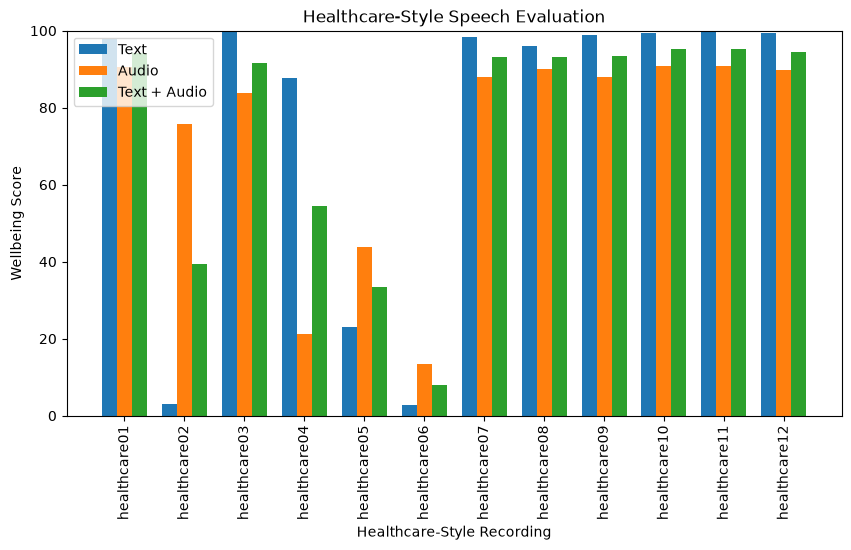

In [33]:
# bar chart for healthcare style speech evaluation
plt.figure(figsize=(10, 5))
plt.bar(x - width,healthcare_df["Text wellbeing"],width,label="Text")
plt.bar(x,healthcare_df["Audio wellbeing"],width,label="Audio")
plt.bar(x + width,healthcare_df["Text + Audio wellbeing"],width,label="Text + Audio")
plt.xticks(x,healthcare_df["Clip"], rotation=90)
plt.ylabel("Wellbeing Score")
plt.xlabel("Healthcare-Style Recording")
plt.title("Healthcare-Style Speech Evaluation")
plt.ylim(0, 100)
plt.legend()
plt.show()

The relative strength of the channels is made obvious by reporting each configuration independently rather than just the fused result, which also reveals how a weak channel might undermine a naive fusion. The per-clip chart and the text-versus-audio disagreement ranking transform the overall accuracy into useful information about when and why the channels clash. Both the conclusion and the independent fusion analysis immediately benefit from these data.

## 7 Text Distress Floor Evaluation

In order to minimise situations in which the other modalities diminish a strong negative text score, this component examines a text distress floor. The fused strain is set to at least 70% of the text strain score when the text strain score is 60 or higher. If not, the current score is kept. The twelve healthcare-style clips' predicted bands are compared to the predictions made before and after this rule was applied.

In [34]:
# Text distress floor tested on clips
TEXT_DISTRESS_THRESHOLD = 60
TEXT_DISTRESS_FLOOR = 0.70

In [35]:
# floor the strain
def floored_strain(row):
    # current fused strain
    strain = 100 - row["Median multimodal wellbeing"]
    # strong verbal distress
    if row["Text strain"] >= TEXT_DISTRESS_THRESHOLD:
        strain = max(strain, TEXT_DISTRESS_FLOOR * row["Text strain"])
    return min(100, strain)

In [36]:
# current prediction
healthcare_df["Current prediction"] = healthcare_df["Median multimodal wellbeing"].apply(wellbeing_band)

In [37]:
# floor prediction
healthcare_df["Floor prediction"]   = (100 - healthcare_df.apply(floored_strain, axis=1)).apply(wellbeing_band)

In [38]:
# expected answer
y_true = healthcare_df["Expected"]
print("Healthcare-style clips:")
for name, col in [("Median multimodal", "Current prediction"), ("With text floor", "Floor prediction")]:
    correct = (y_true == healthcare_df[col]).sum()
    print(f"  {name:<18} {correct}/{len(healthcare_df)} correct")

Healthcare-style clips:
  Median multimodal  6/12 correct
  With text floor    7/12 correct


In [39]:
# changed prediction
changed = healthcare_df[healthcare_df["Current prediction"] != healthcare_df["Floor prediction"]]
print("\nClips whose band changed:")
print(changed[["Clip", "Expected", "Text strain", "Median multimodal wellbeing","Current prediction", "Floor prediction"]].round(1).to_string(index=False))


Clips whose band changed:
        Clip Expected  Text strain  Median multimodal wellbeing Current prediction Floor prediction
healthcare02      Low         96.9                         48.5              Mixed              Low


Band accuracy rises from 50.0% (6/12) to 58.3% (7/12) when the text distress floor is added. In a situation where the other channels weakened the strong negative text, it shifts healthcare02 from Mixed to its anticipated Low band. Other anticipated bands remain unchanged. Although text alone still achieves higher accuracy at 66.7%, this offers initial support for keeping the rule in place. Independent analysis is required to see whether the improvement is generalizable because the rule was tested on these identical clips.

## 8 Conclusion

Out of the twelve healthcare-style recordings, Text's band accuracy is the greatest at 66.7% (8/12). While vision and median multimodal fusion each accomplish 50.0% (6/12), audio and text + audio each achieve 58.3% (7/12). Predictions on this collection are therefore not automatically improved by combining modalities.

By fixing healthcare02, the text distress floor increases median fusion to 58.3% while leaving the other projected bands same. In order to restrict how much a high text strain score can be weakened by other channels, this rule is kept in the final pipeline. Better performance on unseen recordings is not established by this minor development-set improvement, though.

Conflict between modalities and challenges with mixed-band recordings are highlighted in the review. Rather than establishing accurate burnout detection, these findings identify ongoing limits and offer evidence for design modifications. Separate assessment of unseen recordings is necessary for the final pipeline, which includes the distress floor and supporting signals.

## 9 References

[1] A. Radford, J. W. Kim, T. Xu, G. Brockman, C. McLeavey, and I. Sutskever, “Robust speech recognition via large-scale weak supervision,” 2022. [Online]. Available: https://arxiv.org/abs/2212.04356. [Accessed: 31 May 2026].